In [1]:
import mdtraj as md
from jax import random
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from pyscripts.Maths import Maths

In [2]:
fname_prmtop = 'Simulation/ala_deca_peptide.prmtop'
fname_dcd = 'Simulation/decaalanine_1us_split5.dcd'
math = Maths(fname_prmtop)

In [8]:
c = md.load(fname_dcd, top=fname_prmtop)
c = c.superpose(c)
coords = jnp.array(c.xyz)
print(coords.shape)
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)

(10000, 102, 3)
(10000, 306)


389.4651


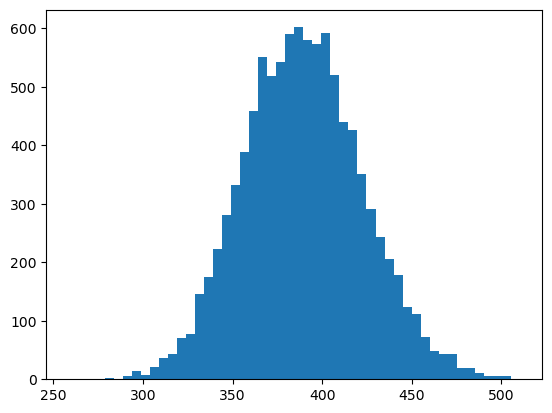

In [9]:
energies = math.ener_fun(coords)
_ = plt.hist(energies, bins=50)
print(energies.mean())

(10000, 403)


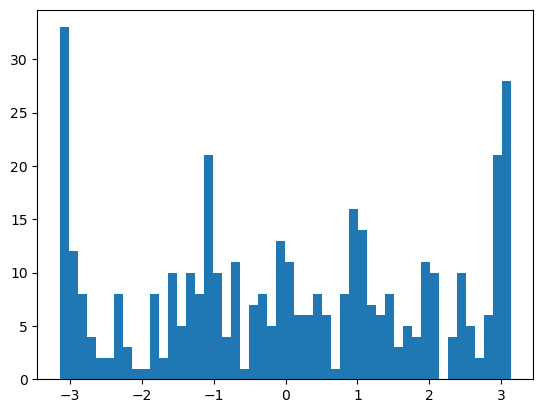

In [18]:
torsions = math.tors_fun(coords)
_ = plt.hist(torsions[69], bins=50)
print(torsions.shape)

In [6]:
a, b = coords[200:300], coords[300:400]
print(a.shape, b.shape)

(100, 306) (100, 306)


In [7]:
matrix = math.rmsd_distance_matrix(a, a)

In [8]:
bandwidth = jnp.min(matrix[jnp.where(matrix != 0)])

In [9]:
kernel = lambda x : jnp.exp(-1*(x**2)/bandwidth)

In [10]:
triu = jnp.triu(kernel(matrix), k=1)
print(triu)

[[0.         0.84677815 0.8187996  ... 0.70867455 0.7356888  0.8337366 ]
 [0.         0.         0.8495992  ... 0.8125414  0.81267804 0.85569453]
 [0.         0.         0.         ... 0.8354079  0.83114713 0.91857904]
 ...
 [0.         0.         0.         ... 0.         0.8325045  0.8077104 ]
 [0.         0.         0.         ... 0.         0.         0.822319  ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [11]:
triu_vals = triu[jnp.where(triu != 0)]

In [12]:
triu_vals.mean()

Array(0.80187464, dtype=float32)

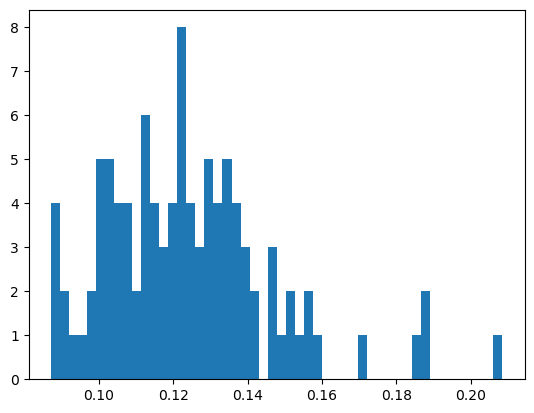

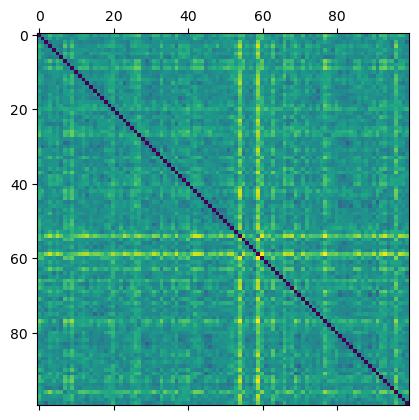

In [13]:
test1 = math.atom_rmsd(a, b)
test2 = math.rmsd_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

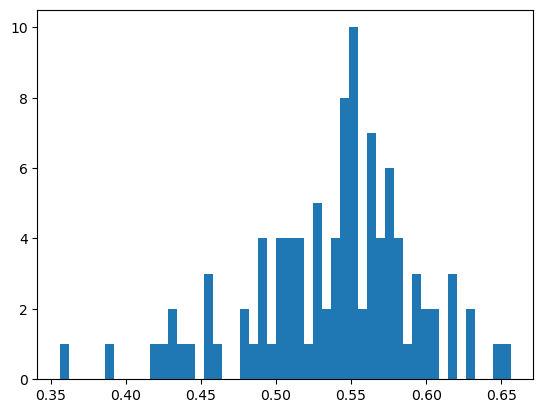

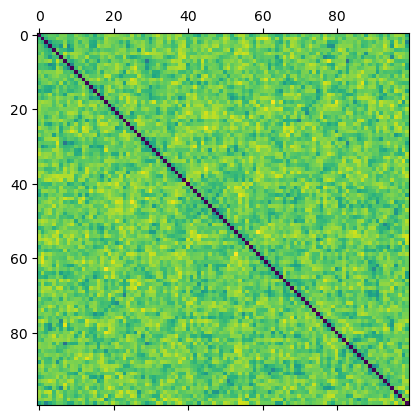

In [14]:
test1 = math.atom_rmtd(a, b)
test2 = math.rmtd_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

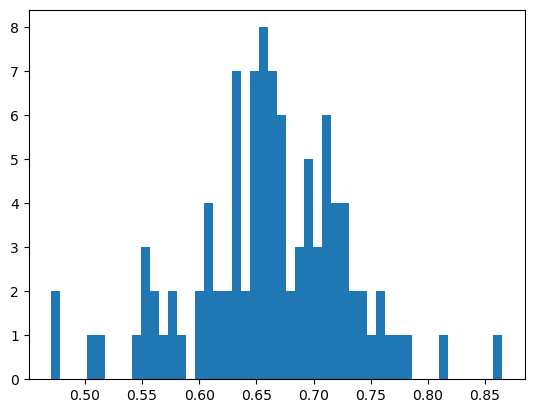

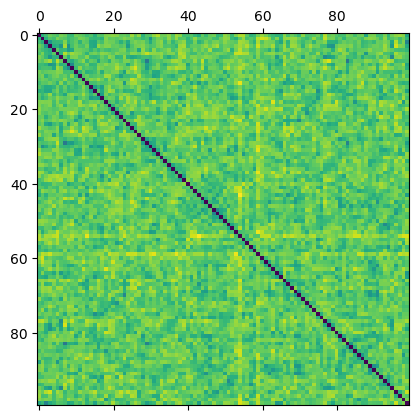

In [15]:
test1 = math.structural_distance(a, b)
test2 = math.structural_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

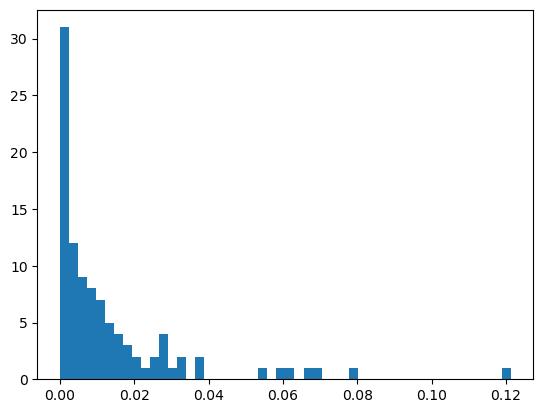

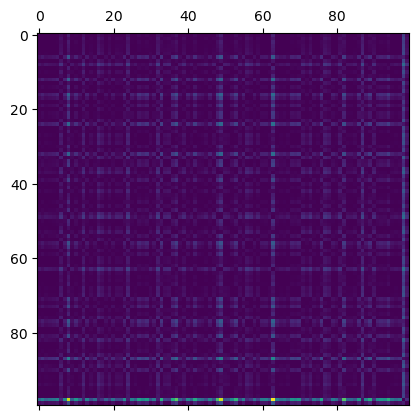

In [16]:
test1 = math.scaled_pot_enr_diff(a, b)
test2 = math.potential_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)